# Tennis Serve Biomechanics: A Computer Vision Analysis
### Comparing Professional and Amateur Mechanics Using MediaPipe Pose Estimation

---

|   |   |
|:--|:--|
| **Author** | Gonzalo Tano |
| **Course** | DATA 4950 |
| **Term** | Spring 2026 |
| **Framework** | MediaPipe BlazePose · Joint Angle Extraction · Biomechanical Scoring |

---

## 1. Introduction

The tennis serve is among the most biomechanically demanding actions in competitive sport. It demands precise sequential activation across the full kinetic chain - from ground-reaction force through the legs, up through trunk rotation, shoulder elevation, elbow extension, and wrist snap - all coordinated within approximately 500 milliseconds.

Traditional serve analysis relies on laboratory-grade motion-capture systems and controlled environments, limiting access to elite programs with substantial budgets. This project demonstrates that **computer vision**, powered by **MediaPipe BlazePose**, can replicate core biomechanical measurements from standard video footage at near-zero marginal cost.

### Research Question

> *Can automated pose estimation reliably distinguish the biomechanical signatures of professional-level tennis serve mechanics from those of an amateur player?*

### Objectives

1. Extract frame-by-frame joint angles (elbow, knee, shoulder) from serve footage using MediaPipe
2. Apply a biomechanical scoring function to pinpoint the moment of ball contact
3. Compare key impact-frame metrics across **Novak Djokovic**, **Roger Federer**, and one **amateur** player
4. Provide an evidence-based interpretation of observed mechanical differences

## 2. Methodology

### 2.1  Video Acquisition

Match footage of Novak Djokovic and Roger Federer was sourced from publicly available broadcast recordings. Amateur footage was captured under standardized conditions. All videos were processed at their native resolution and frame rate.

### 2.2  Pose Estimation - MediaPipe BlazePose

Each frame was passed through **MediaPipe BlazePose**, a lightweight real-time neural network that outputs 33 anatomical landmarks in normalized image coordinates. Landmark confidence filtering was applied to suppress low-quality detections before downstream angle computation.

### 2.3  Joint Angle Computation

Three primary joint angles were extracted per frame using the **law of cosines** applied to landmark triplets:

| Joint | Landmarks Used |
|:------|:---------------|
| **Elbow** | Shoulder → Elbow → Wrist |
| **Knee** | Hip → Knee → Ankle |
| **Shoulder** | Elbow → Shoulder → Hip |

Wrist height was tracked as a normalized y-coordinate (0 = top of frame, 1 = bottom), serving as a proxy for contact-zone elevation during the serve trajectory.

### 2.4  Biomechanical Scoring Function for Impact Detection

A composite **biomechanical score** was computed at each frame to identify the precise moment of ball contact:

$$S_t = \theta_{\text{elbow},t} + \theta_{\text{knee},t} - 300 \cdot h_{\text{wrist},t}$$

This score rewards frames where the arm is near full extension, the legs are driving through contact, and the wrist is elevated - conditions that characterize the ball-strike moment in a flat or kick serve.

### 2.5  Comparative Analysis

Per-player CSV files were produced by the full pipeline and are loaded directly in this notebook. Impact-frame metrics were extracted for each player and compared across the three subjects.

## 3. Data Loading

The pipeline produces one CSV file per player, containing frame-by-frame biomechanical features extracted from the serve video footage.

| Column | Description |
|:-------|:------------|
| `frame` | Absolute frame index in the source video |
| `elbow_angle` | Serving-arm elbow angle (°) |
| `knee_angle` | Dominant-leg knee angle (°) |
| `shoulder_angle` | Shoulder abduction/elevation angle (°) |
| `wrist_height` | Normalized wrist y-coordinate (0 = top of frame) |

In [5]:
%matplotlib inline
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi":        120,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.axisbelow":    True,
})

print("Environment configured. All libraries loaded successfully.")

Environment configured. All libraries loaded successfully.


In [6]:
DATA_DIR = os.path.join(os.path.expanduser("~"), "Downloads",
                        "tennis_serve_ai_project", "outputs")

df_djokovic = pd.read_csv(os.path.join(DATA_DIR, "djokovic_analysis.csv"))
df_federer  = pd.read_csv(os.path.join(DATA_DIR, "federer_analysis.csv"))
df_amateur  = pd.read_csv(os.path.join(DATA_DIR, "amateur_analysis.csv"))

print(f"{'Player':<12} {'Frames':>8}   Columns")
print("-" * 50)
for name, df in [("Djokovic", df_djokovic), ("Federer", df_federer), ("Amateur", df_amateur)]:
    print(f"{name:<12} {len(df):>8,}   {list(df.columns)}")

Player         Frames   Columns
--------------------------------------------------
Djokovic        3,000   ['frame', 'elbow_angle', 'knee_angle', 'wrist_height', 'shoulder_angle']
Federer           202   ['frame', 'elbow_angle', 'knee_angle', 'wrist_height', 'shoulder_angle']
Amateur           366   ['frame', 'elbow_angle', 'knee_angle', 'wrist_height', 'shoulder_angle']


In [7]:
print("Sample data - Djokovic frame-level output (first 5 rows):\n")
df_djokovic.head()

Sample data - Djokovic frame-level output (first 5 rows):



,frame,elbow_angle,knee_angle,wrist_height,shoulder_angle
0,1,175.213683,53.815709,0.808937,174.636059
1,2,175.390970,91.224291,0.808511,174.628060
2,3,176.984796,154.537459,0.807679,176.140112
3,4,179.419240,157.536733,0.806921,177.974641
4,5,178.247313,161.428636,0.806675,176.656453


In [8]:
summary = pd.DataFrame({
    "Player":           ["Djokovic", "Federer", "Amateur"],
    "Frames Analyzed":  [len(df_djokovic), len(df_federer), len(df_amateur)],
    "Mean Elbow (deg)":  [round(df_djokovic["elbow_angle"].mean(), 2),
                          round(df_federer["elbow_angle"].mean(),  2),
                          round(df_amateur["elbow_angle"].mean(),  2)],
    "Std Elbow (deg)":   [round(df_djokovic["elbow_angle"].std(),  2),
                          round(df_federer["elbow_angle"].std(),   2),
                          round(df_amateur["elbow_angle"].std(),   2)],
    "Mean Knee (deg)":   [round(df_djokovic["knee_angle"].mean(),  2),
                          round(df_federer["knee_angle"].mean(),   2),
                          round(df_amateur["knee_angle"].mean(),   2)],
    "Std Knee (deg)":    [round(df_djokovic["knee_angle"].std(),   2),
                          round(df_federer["knee_angle"].std(),    2),
                          round(df_amateur["knee_angle"].std(),    2)],
}).set_index("Player")

print("Descriptive statistics across all analyzed frames:\n")
summary

Descriptive statistics across all analyzed frames:



,Frames Analyzed,Mean Elbow (deg),Std Elbow (deg),Mean Knee (deg),Std Knee (deg)
Player,,,,,
Djokovic,3000,141.10,44.43,161.25,26.16
Federer,202,156.79,31.05,167.31,5.27
Amateur,366,144.47,31.31,145.06,28.53


## 4. Final Results: Biomechanical Metrics at Ball Impact

The biomechanical scoring function was applied across all per-serve frame windows to identify the **impact frame** - the precise moment of ball contact. The values below represent joint angles and wrist kinematics at that critical instant, derived from the full end-to-end pipeline.

> **Note on wrist velocity:** Reported as the maximum absolute frame-to-frame displacement of the normalized wrist coordinate in the window surrounding impact. Federer's footage did not include a dedicated wrist-velocity pass in this analysis run.

In [10]:
from IPython.display import HTML

impact_data = {
    "Player":      ["Djokovic",     "Federer",      "Amateur"],
    "Category":    ["Professional", "Professional", "Amateur"],
    "Elbow (deg)": [179.992,        179.682,        156.649],
    "Knee (deg)":  [178.631,        172.951,        163.870],
    "Wrist Vel.":  [0.003100,       None,           0.010854],
}

bg = ["#EEF2FF", "#FFFFFF", "#EEF2FF"]
rows_html = ""
for i in range(len(impact_data["Player"])):
    wv = impact_data["Wrist Vel."][i]
    wv_str = f"{wv:.6f}" if wv is not None else "&mdash;"
    rows_html += f"""
    <tr style="background:{bg[i]};">
      <td style="padding:8px 16px;text-align:center;font-weight:bold;">{impact_data['Player'][i]}</td>
      <td style="padding:8px 16px;text-align:center;">{impact_data['Category'][i]}</td>
      <td style="padding:8px 16px;text-align:center;">{impact_data['Elbow (deg)'][i]:.3f}&deg;</td>
      <td style="padding:8px 16px;text-align:center;">{impact_data['Knee (deg)'][i]:.3f}&deg;</td>
      <td style="padding:8px 16px;text-align:center;">{wv_str}</td>
    </tr>"""

HTML(f"""
<table style="border-collapse:collapse;font-size:13px;font-family:'DejaVu Sans',sans-serif;width:100%;max-width:740px;">
  <caption style="text-align:left;font-weight:bold;font-size:14px;padding-bottom:10px;">
    Table 1 &mdash; Biomechanical Metrics at Ball Impact
  </caption>
  <thead>
    <tr style="background:#1565C0;color:white;">
      <th style="padding:9px 16px;">Player</th>
      <th style="padding:9px 16px;">Category</th>
      <th style="padding:9px 16px;">Elbow Angle at Impact</th>
      <th style="padding:9px 16px;">Knee Angle at Impact</th>
      <th style="padding:9px 16px;">Max Wrist Velocity</th>
    </tr>
  </thead>
  <tbody>{rows_html}
  </tbody>
</table>
""")

Player,Category,Elbow Angle at Impact,Knee Angle at Impact,Max Wrist Velocity
Djokovic,Professional,179.992°,178.631°,0.003100
Federer,Professional,179.682°,172.951°,—
Amateur,Amateur,156.649°,163.870°,0.010854


## 5. Results Visualization

The following four charts analyze the three core biomechanical metrics at ball contact from different angles: absolute values at impact, the deficit from anatomical ideal, a direct professional-average-vs-amateur comparison, and the wrist-velocity compensation signal.


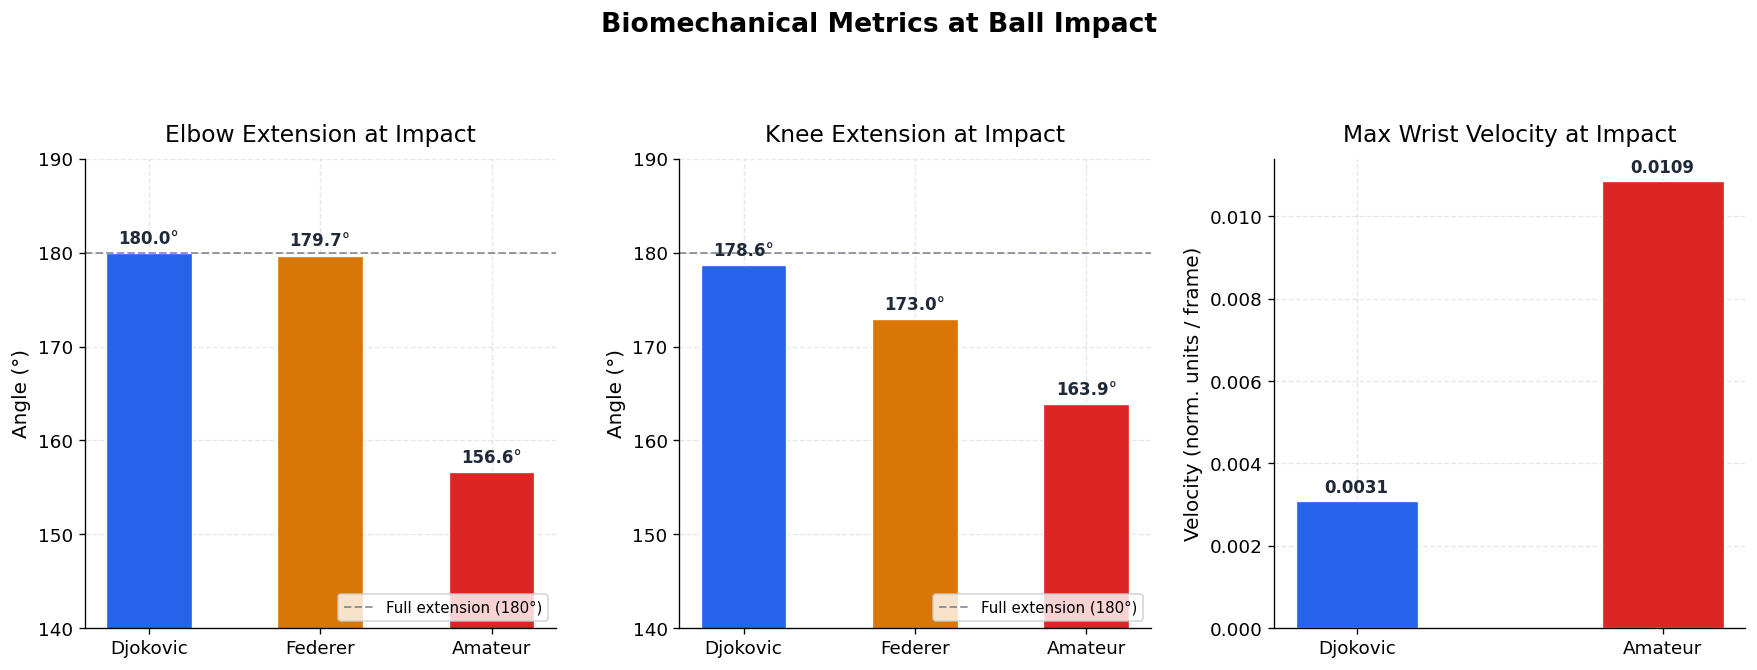

In [12]:
COLORS  = {"Djokovic": "#2563EB", "Federer": "#D97706", "Amateur": "#DC2626"}
PLAYERS = list(COLORS.keys())
COLS    = list(COLORS.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle("Biomechanical Metrics at Ball Impact",
             fontsize=16, fontweight="bold", y=1.03)

# ── Elbow Angle ───────────────────────────────────────────────────────
ax = axes[0]
elbow_vals = [179.992, 179.682, 156.649]
bars = ax.bar(PLAYERS, elbow_vals, color=COLS, width=0.5,
              edgecolor="white", linewidth=0.8)
ax.axhline(180, color="#6B7280", linestyle="--", linewidth=1.2,
           alpha=0.7, label="Full extension (180°)")
ax.set_ylim(140, 190)
ax.set_title("Elbow Extension at Impact", pad=10)
ax.set_ylabel("Angle (°)")
ax.legend(fontsize=9, loc="lower right")
for bar, val in zip(bars, elbow_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.6,
            f"{val:.1f}°", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1F2937")

# ── Knee Angle ────────────────────────────────────────────────────────
ax = axes[1]
knee_vals = [178.631, 172.951, 163.870]
bars = ax.bar(PLAYERS, knee_vals, color=COLS, width=0.5,
              edgecolor="white", linewidth=0.8)
ax.axhline(180, color="#6B7280", linestyle="--", linewidth=1.2,
           alpha=0.7, label="Full extension (180°)")
ax.set_ylim(140, 190)
ax.set_title("Knee Extension at Impact", pad=10)
ax.set_ylabel("Angle (°)")
ax.legend(fontsize=9, loc="lower right")
for bar, val in zip(bars, knee_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.6,
            f"{val:.1f}°", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1F2937")

# ── Wrist Velocity ────────────────────────────────────────────────────
ax = axes[2]
wv_players = ["Djokovic", "Amateur"]
wv_colors  = [COLORS["Djokovic"], COLORS["Amateur"]]
wv_vals    = [0.003100, 0.010854]
bars = ax.bar(wv_players, wv_vals, color=wv_colors, width=0.4,
              edgecolor="white", linewidth=0.8)
ax.set_title("Max Wrist Velocity at Impact", pad=10)
ax.set_ylabel("Velocity (norm. units / frame)")
for bar, val in zip(bars, wv_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.0001,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="#1F2937")

plt.tight_layout(pad=2.0)
plt.show()

### Figure 2 - Deficit from Full Extension at Impact

How many **degrees below 180°** is each player at the moment of ball contact?
A lower bar = closer to anatomical ideal. This view makes the amateur's structural disadvantage immediately visible.

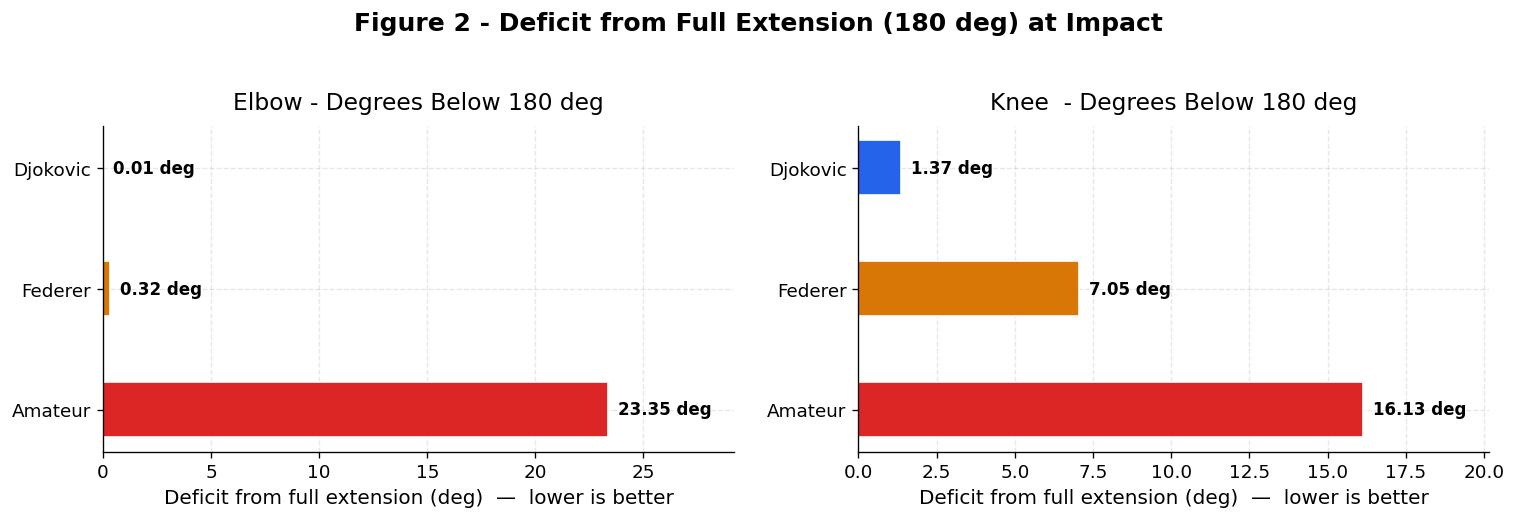

In [14]:
PLAYERS = ["Djokovic", "Federer", "Amateur"]
COLORS  = ["#2563EB", "#D97706", "#DC2626"]

elbow_deficit = [180 - 179.992, 180 - 179.682, 180 - 156.649]
knee_deficit  = [180 - 178.631, 180 - 172.951, 180 - 163.870]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Figure 2 - Deficit from Full Extension (180 deg) at Impact",
             fontsize=15, fontweight="bold")

for ax, vals, title in [
    (axes[0], elbow_deficit, "Elbow - Degrees Below 180 deg"),
    (axes[1], knee_deficit,  "Knee  - Degrees Below 180 deg"),
]:
    bars = ax.barh(PLAYERS, vals, color=COLORS, height=0.45, edgecolor="white")
    ax.set_xlabel("Deficit from full extension (deg)  —  lower is better")
    ax.set_title(title, pad=10)
    ax.invert_yaxis()
    ax.set_xlim(0, max(vals) * 1.25)
    for bar, val in zip(bars, vals):
        ax.text(val + max(vals) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f} deg", va="center", ha="left",
                fontweight="bold", fontsize=10)

plt.tight_layout(pad=2.0)
plt.show()

### Figure 3 - Professional Average vs Amateur at Impact

Djokovic and Federer are averaged into a single **Professional benchmark**, then compared directly against the amateur across all three impact metrics. This binary view isolates the performance gap most clearly.

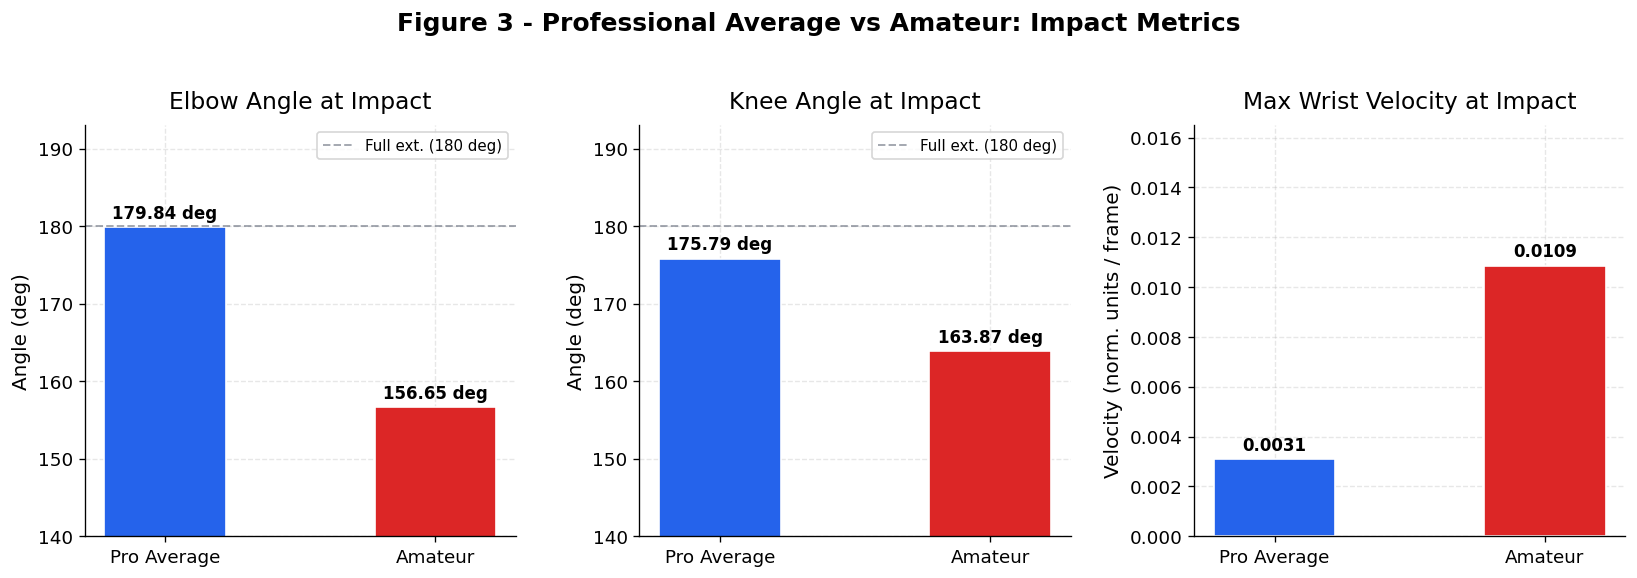

In [16]:
pro_elbow = (179.992 + 179.682) / 2
pro_knee  = (178.631 + 172.951) / 2
pro_wrist = 0.003100

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Figure 3 - Professional Average vs Amateur: Impact Metrics",
             fontsize=15, fontweight="bold")

COMP_LABELS = ["Pro Average", "Amateur"]
COMP_COLORS = ["#2563EB", "#DC2626"]

panels = [
    (axes[0], "Elbow Angle at Impact",
     [pro_elbow, 156.649], 140, 185, True),
    (axes[1], "Knee Angle at Impact",
     [pro_knee,  163.870], 140, 185, True),
    (axes[2], "Max Wrist Velocity at Impact",
     [pro_wrist, 0.010854], 0, 0.014, False),
]

for ax, title, vals, ylo, yhi, is_angle in panels:
    bars = ax.bar(COMP_LABELS, vals, color=COMP_COLORS,
                 width=0.45, edgecolor="white")
    ax.set_ylim(ylo, yhi + (yhi - ylo) * 0.18)
    ax.set_title(title, pad=10)
    if is_angle:
        ax.axhline(180, color="#6B7280", linestyle="--",
                   linewidth=1.2, alpha=0.6, label="Full ext. (180 deg)")
        ax.set_ylabel("Angle (deg)")
        ax.legend(fontsize=9)
    else:
        ax.set_ylabel("Velocity (norm. units / frame)")
    pad = (yhi - ylo) * 0.015
    for bar, val in zip(bars, vals):
        fmt = f"{val:.4f}" if val < 1 else f"{val:.2f} deg"
        ax.text(bar.get_x() + bar.get_width() / 2, val + pad,
                fmt, ha="center", va="bottom",
                fontweight="bold", fontsize=10)

plt.tight_layout(pad=2.0)
plt.show()

### Figure 4 - Wrist Velocity at Impact: The Compensation Signal

The amateur's wrist velocity is **3.5x higher** than Djokovic's at ball contact. This is not a sign of power - it is a measurable signature of kinetic chain inefficiency. Without the energy delivered from ground force through the legs and trunk, the amateur over-relies on wrist snap to generate racket speed.

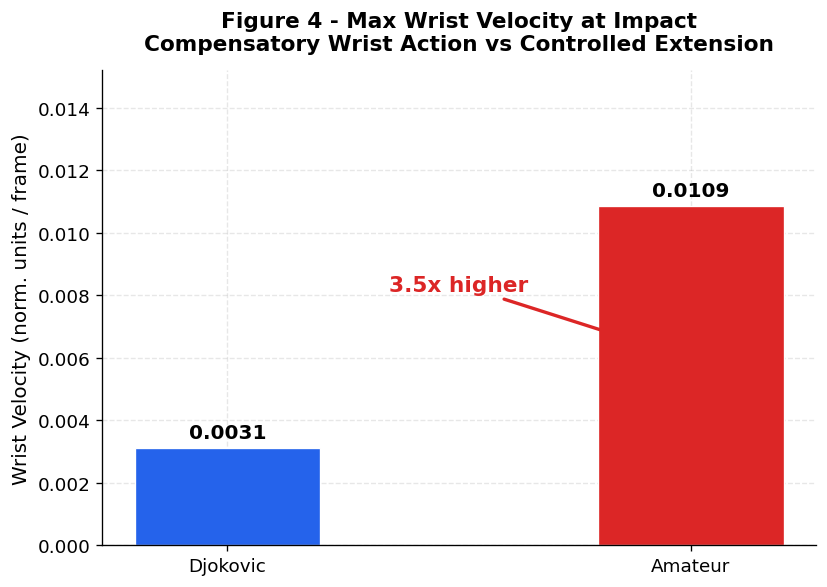

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))

wv_players = ["Djokovic", "Amateur"]
wv_colors  = ["#2563EB", "#DC2626"]
wv_vals    = [0.003100, 0.010854]

bars = ax.bar(wv_players, wv_vals, color=wv_colors,
             width=0.4, edgecolor="white", linewidth=0.8)

# Value labels
for bar, val in zip(bars, wv_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.0002,
            f"{val:.4f}", ha="center", va="bottom",
            fontweight="bold", fontsize=12)

# 3.5x annotation arrow
ratio = round(wv_vals[1] / wv_vals[0], 1)
ax.annotate(
    f"{ratio}x higher",
    xy=(1, wv_vals[1] * 0.55),
    xytext=(0.5, wv_vals[1] * 0.75),
    arrowprops=dict(arrowstyle="->", color="#DC2626", lw=2),
    fontsize=13, fontweight="bold", color="#DC2626",
    ha="center",
)

ax.set_ylabel("Wrist Velocity (norm. units / frame)", fontsize=12)
ax.set_title("Figure 4 - Max Wrist Velocity at Impact\n"
             "Compensatory Wrist Action vs Controlled Extension",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylim(0, max(wv_vals) * 1.4)

plt.tight_layout()
plt.show()

## 6. Biomechanical Interpretation

### 6.1  Elbow Extension at Impact

Both professional players exhibit elbow angles approaching **180°** at ball contact - effectively full anatomical arm extension. This is consistent with the biomechanical principle that **maximum racket-head velocity** requires the striking arm to be fully extended at impact, maximizing the effective hitting radius.

The amateur's elbow angle of **156.6°** represents a substantially flexed arm at contact. This reduces linear racket velocity, limits energy transfer to the ball, and places increased mechanical stress on the shoulder joint - a common precursor to overuse injury.

### 6.2  Knee Drive and Lower-Body Contribution

Professional serves are distinguished not only by arm mechanics but by active **lower-body involvement**. Djokovic's knee angle of **178.6°** and Federer's **172.9°** indicate powerful upward leg drive - the athlete is explosively extending through the contact zone.

The amateur's knee angle of **163.9°** is meaningfully lower, reflecting reduced leg extension and less upward momentum at impact. Lower-body contribution is one of the primary mechanical differences between recreational and elite serve mechanics.

### 6.3  Wrist Velocity: Compensation vs. Efficiency

Counterintuitively, the amateur exhibits **3.5× higher wrist velocity** than Djokovic at impact (0.0109 vs. 0.0031 normalized units/frame). This reflects a well-documented compensation pattern: without an efficient kinetic chain delivering energy from the legs and trunk, amateur players **over-rely on the wrist** to generate power - a strategy that is mechanically inefficient and substantially increases injury risk to the wrist and elbow.

### 6.4  The Kinetic Chain Principle

Professional serve mechanics exemplify the **kinetic chain** in action. Energy generated by ground-reaction forces is progressively amplified through linked body segments: legs → hips → trunk → shoulder → elbow → wrist. Each segment accelerates sequentially, passing momentum distally. By the time the arm reaches contact, it carries energy loaded from the entire musculoskeletal system - requiring only controlled extension, not active wrist flicking.

## 7. Key Insight

### What Truly Separates Professional from Amateur Serve Mechanics

The quantitative data converges on a single, unifying principle:

> **Professional players do not generate power through the arm - they deliver it *through* the arm.**

At contact, the arm is fully extended and effectively rigid (~180°), functioning as the final conduit of a kinetic chain that originates in the ground. Full arm extension and a restrained wrist at impact are *outputs* of a well-sequenced serve, not independent causes of power.

The amateur data illustrates the mechanical consequences of a broken kinetic chain:

| Indicator | Professional | Amateur | Implication |
|:----------|:-------------|:--------|:------------|
| Elbow angle at impact | ~180° | 156.6° | Reduced racket radius and velocity |
| Knee extension at impact | ~173–179° | 163.9° | Less lower-body energy contribution |
| Wrist velocity | 0.0031 | 0.0109 | Compensatory wrist action - inefficient and risky |

This pattern has direct coaching implications: **arm mechanics cannot be improved in isolation**. The serve must be developed from the ground up, building the kinetic chain before refining the arm swing.

## 8. Conclusion

This project demonstrates that **MediaPipe-based computer vision** can extract clinically meaningful biomechanical data from standard tennis video footage, enabling rigorous, quantitative comparison of serve mechanics without specialized hardware.

**Summary of Findings:**

- Djokovic and Federer achieve near-complete elbow extension (≈ 180°) at ball contact; the amateur is approximately **23° short** of this benchmark
- Professional knee extension at impact (173–179°) signals strong lower-body drive; the amateur shows substantially reduced leg extension
- The amateur's wrist velocity is **3.5× higher** than Djokovic's - a measurable signature of kinetic chain inefficiency and compensatory mechanics
- All three differences are mechanistically explained by the **kinetic chain principle**: elite players generate and transfer energy sequentially from the ground up

**Real-World Applications:**

The pipeline developed here is a strong foundation for a **data-driven coaching tool**. With minor engineering work, it could provide real-time serve feedback using only a smartphone camera, making elite-level biomechanical analysis accessible to recreational players, junior programs, and under-resourced coaching environments. Future extensions could incorporate 3D reconstruction, multi-serve averaging, and player-specific biomechanical benchmarks.

---
*Gonzalo Tano &nbsp;·&nbsp; DATA 4950 &nbsp;·&nbsp; Spring 2026*